# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [7]:
# 코랩 환경: 구글 드라이브를 코랩에 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [9]:
# housing.xls가 포함된 경로를 저장해봅시다.
PATH = '/content/drive/MyDrive/'

In [10]:
# 본인 구글 드라이브에 업로드한 housing.xls 파일의 주소를 넣어주세요!
house = pd.read_excel(PATH+'housing.xls')

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

과제2 참고

In [13]:
house.head()

house.info()

house.describe()

house.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


(506, 14)

# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

In [14]:
# NaN의 개수 구하기

print(house.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

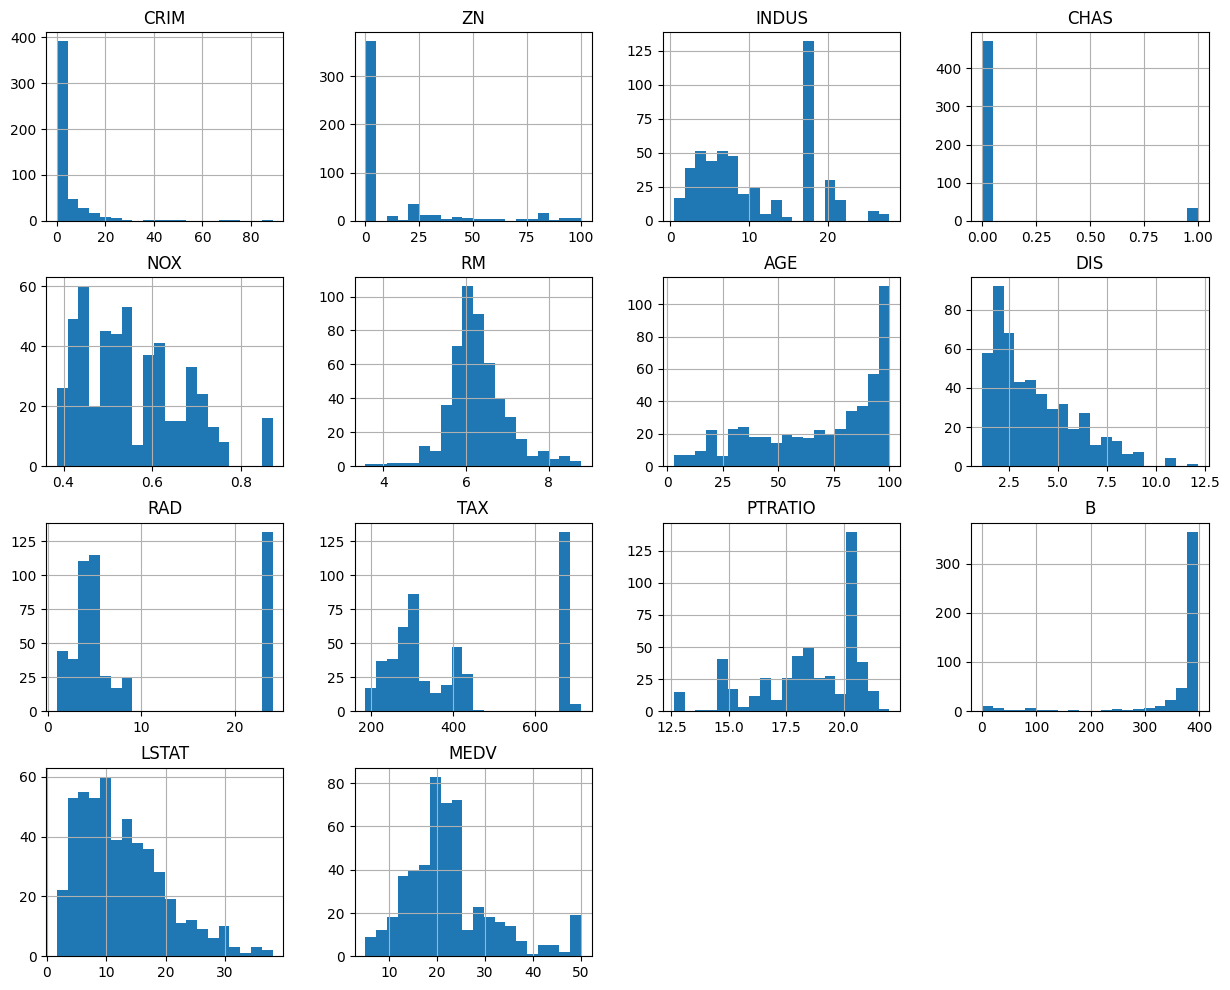

In [15]:
# Histogram

house.hist(bins=20, figsize=(15,12))
plt.show()

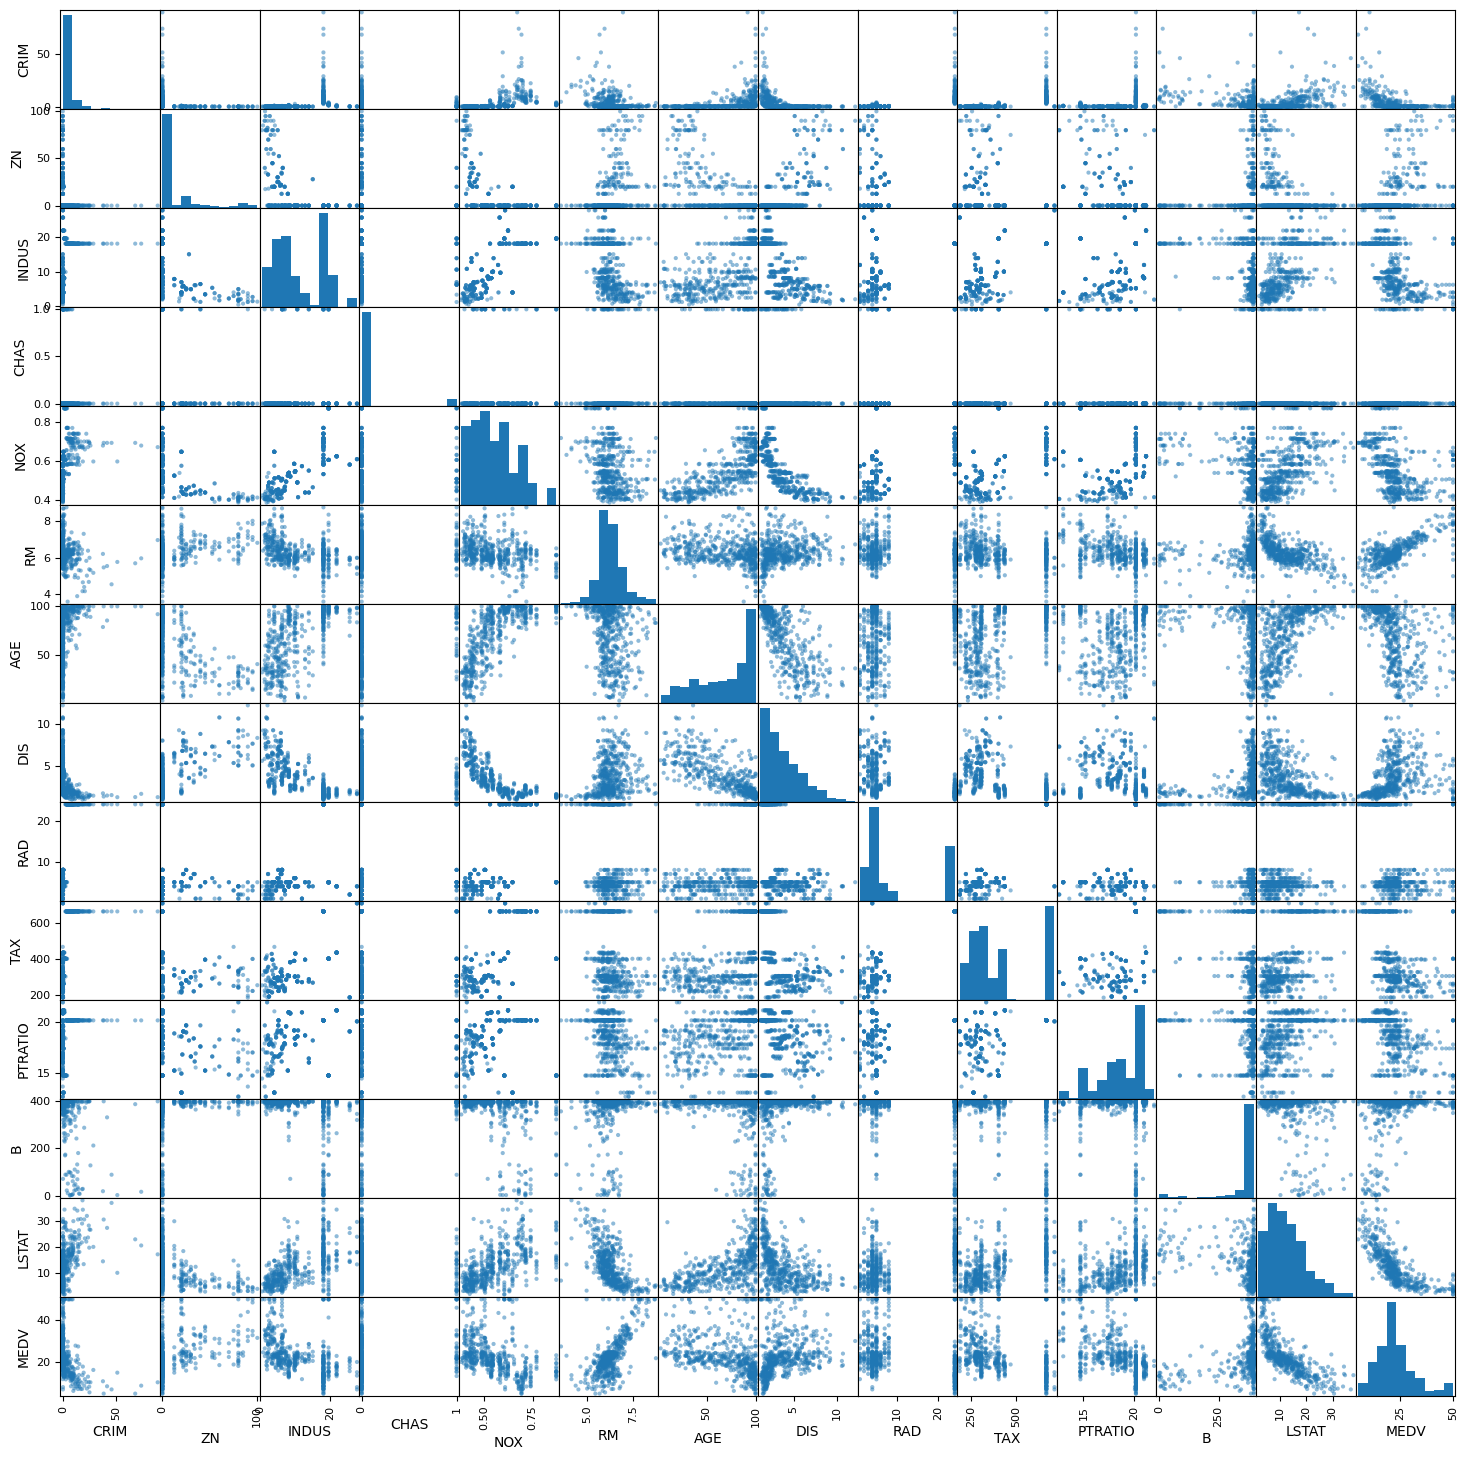

In [16]:
# Scatterplot Matrix

pd.plotting.scatter_matrix(house, figsize=(18, 18), diagonal='hist')
plt.show()

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

In [17]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns
vif

,VIF Factor,features
0,2.131404,CRIM
1,2.910004,ZN
2,14.485874,INDUS
3,1.176266,CHAS
4,74.004269,NOX
5,136.101743,RM
6,21.398863,AGE
7,15.430455,DIS
8,15.369980,RAD
9,61.939713,TAX


## Q3-2.
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

In [19]:
vif = pd.DataFrame()
x_data = house.drop( 'RM' ,axis=1) # VIF 높은 변수 기입
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.110287,CRIM
1,2.889159,ZN
2,14.202832,INDUS
3,1.174535,CHAS
4,62.073615,NOX
5,20.752654,AGE
6,14.258330,DIS
7,15.134503,RAD
8,61.603579,TAX
9,69.068505,PTRATIO


**house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

In [20]:
# train_test_split

X = house.drop('MEDV', axis=1)
y = house['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(404, 13) (102, 13) (404,) (102,)


# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [21]:
# StandardScaler

# CHAS(더미변수), RAD(인덱스형 변수)는 표준화 대상에서 제외
scale_cols = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# X_train은 fit_transform, X_test는 transform!
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

X_train_scaled.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,0,0.489252,-1.428069,1.028015,-0.802173,24,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,0,-0.157233,-0.680087,-0.431199,0.324349,4,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,0,-1.008723,-0.402063,-1.618599,1.330697,1,-0.602724,-0.637176,0.065297,-0.651595
423,0.388230,-0.500320,1.033237,0,0.489252,-0.300450,0.591681,-0.839240,24,1.578434,0.845343,-3.868193,1.525387
19,-0.325282,-0.500320,-0.413160,0,-0.157233,-0.831094,0.033747,-0.005494,4,-0.584648,1.204741,0.379119,-0.165787


# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

In [22]:
# KFold, cross_val_score, cross_validation 이용

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_list, mae_list, rmse_list, r2_list = [], [], [], []

X_arr = X_train_scaled.values
y_arr = y_train.values

for fold, (train_idx, val_idx) in enumerate(kf.split(X_arr), 1):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_val, y_pred)

    mse_list.append(mse)
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)

    print(f"--- Fold {fold} ---")
    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    print(f"Coefficients: {model.coef_}")
    print(f"Intercept: {model.intercept_}\n")

print("=== 5-fold 평균 성능 ===")
print(f"평균 MSE : {np.mean(mse_list):.4f}")
print(f"평균 MAE : {np.mean(mae_list):.4f}")
print(f"평균 RMSE: {np.mean(rmse_list):.4f}")
print(f"평균 R2  : {np.mean(r2_list):.4f}")

--- Fold 1 ---
MSE: 23.2864, MAE: 3.2108, RMSE: 4.8256, R2: 0.6725
Coefficients: [-0.94812889  0.75860569  0.30089583  3.00762597 -2.22748976  3.51291195
 -0.0701652  -3.21933289  0.22020054 -1.4566606  -2.08154936  1.15725598
 -3.28121084]
Intercept: 20.50476706463811

--- Fold 2 ---
MSE: 23.5646, MAE: 3.4965, RMSE: 4.8543, R2: 0.7601
Coefficients: [-1.05807326  0.74220183  0.10490298  3.09299413 -2.01430949  2.79994632
 -0.17481654 -3.32611962  0.24295321 -1.74209102 -1.77657178  1.09336037
 -3.97212925]
Intercept: 20.10133952731695

--- Fold 3 ---
MSE: 36.4745, MAE: 3.7736, RMSE: 6.0394, R2: 0.5895
Coefficients: [-0.83960069  0.68397371  0.56370453  0.62831766 -1.64117107  3.49407283
 -0.31189726 -2.65099913  0.22502761 -2.05077    -2.18048357  1.23827918
 -2.99696129]
Intercept: 20.578415408774838

--- Fold 4 ---
MSE: 25.7558, MAE: 3.9217, RMSE: 5.0750, R2: 0.7592
Coefficients: [-1.0337213   0.32691448 -0.03308526  4.61419375 -1.99624146  2.92001074
 -0.29251259 -2.88703739  0.2851

### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

In [23]:
# 다중공선성을 불러일으키는 변수 제거
house_new = house.drop(['RM'], axis=1) # VIF 높은 변수들 기입

In [26]:
# train_test_split

X_new = house_new.drop('MEDV', axis=1)
y_new = house_new['MEDV']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# StandardScaler

scale_cols_new = ['CRIM', 'ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

scaler_new = StandardScaler()
X_train_new_scaled = X_train_new.copy()
X_test_new_scaled = X_test_new.copy()

X_train_new_scaled[scale_cols_new] = scaler_new.fit_transform(X_train_new[scale_cols_new])
X_test_new_scaled[scale_cols_new] = scaler_new.transform(X_test_new[scale_cols_new])

# KFold, cross_val_score, cross_validation 이용

kf_new = KFold(n_splits=5, shuffle=True, random_state=42)

mse_list_new, mae_list_new, rmse_list_new, r2_list_new = [], [], [], []

X_arr_new = X_train_new_scaled.values
y_arr_new = y_train_new.values

for fold, (train_idx, val_idx) in enumerate(kf_new.split(X_arr_new), 1):
    X_tr, X_val = X_arr_new[train_idx], X_arr_new[val_idx]
    y_tr, y_val = y_arr_new[train_idx], y_arr_new[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_val, y_pred)

    mse_list_new.append(mse)
    mae_list_new.append(mae)
    rmse_list_new.append(rmse)
    r2_list_new.append(r2)

    print(f"--- Fold {fold} (RM 제거) ---")
    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    print(f"Coefficients: {model.coef_}")
    print(f"Intercept: {model.intercept_}\n")

print("=== 5-fold 평균 성능 (RM 제거 후) ===")
print(f"평균 MSE : {np.mean(mse_list_new):.4f}")
print(f"평균 MAE : {np.mean(mae_list_new):.4f}")
print(f"평균 RMSE: {np.mean(rmse_list_new):.4f}")
print(f"평균 R2  : {np.mean(r2_list_new):.4f}")

print("\n=== Q6(전체 변수) vs Q6-1(RM 제거) 비교 ===")
print(f"평균 MSE: {np.mean(mse_list):.4f}  ->  {np.mean(mse_list_new):.4f}")
print(f"평균 R2 : {np.mean(r2_list):.4f}  ->  {np.mean(r2_list_new):.4f}")

--- Fold 1 (RM 제거) ---
MSE: 21.9920, MAE: 3.4107, RMSE: 4.6896, R2: 0.6907
Coefficients: [-1.08023413  1.2666314  -0.32258618  3.39171937 -2.64424918  0.95731476
 -3.88750215  0.34869457 -1.97907451 -2.68616237  0.8346689  -5.67293963]
Intercept: 19.30454011501085

--- Fold 2 (RM 제거) ---
MSE: 33.0717, MAE: 3.8190, RMSE: 5.7508, R2: 0.6633
Coefficients: [-1.02441133  1.18070045 -0.39142303  3.68786031 -2.5538083   0.60043299
 -3.88582154  0.34664418 -2.20767349 -2.169459    0.82394382 -5.66390338]
Intercept: 19.0304442500753

--- Fold 3 (RM 제거) ---
MSE: 36.8967, MAE: 4.2558, RMSE: 6.0743, R2: 0.5847
Coefficients: [-1.01103591  1.18074611  0.01057929  1.56292291 -2.11373913  0.5141353
 -3.39316103  0.39929184 -2.78428792 -2.79963044  0.77768608 -5.38999103]
Intercept: 18.9426663105051

--- Fold 4 (RM 제거) ---
MSE: 34.5162, MAE: 4.5133, RMSE: 5.8750, R2: 0.6773
Coefficients: [-1.0961599   0.61929294 -0.60036232  4.52675663 -2.28075825  0.41933803
 -3.3085277   0.40849945 -1.93286315 -2.646

VIF 기준으로는 RM(≈136)이 가장 높게 나와 다중공선성이 의심되었으나, 실제로 RM을 제거하고 5-fold CV로 재검증한 결과 평균 MSE가 24.32→28.83, R²가 0.718→0.670으로 오히려 성능이 저하되었다.

이는 RM(평균 방 개수)이 MEDV(집값) 예측에 실질적으로 중요한 정보를 담고 있기 때문이며, VIF가 높다고 해서 무조건 제거하는 것이 능사가 아니라 실제 예측 성능(MSE 등)으로 최종 판단해야 함을 보여준다.

# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

# param_grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'fit_intercept': [True, False]
}

scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']

grid_search = GridSearchCV(
    estimator=Lasso(),
    param_grid=param_grid,
    scoring=scoring,
    refit='neg_mean_squared_error',
    cv=5
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score (neg_mean_squared_error):", grid_search.best_score_)

best_lasso = grid_search.best_estimator_
y_pred = best_lasso.predict(X_test_scaled)
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2 :", r2_score(y_test, y_pred))


Best Params: {'alpha': 0.01, 'fit_intercept': True}
Best CV Score (neg_mean_squared_error): -23.66799421099412
Test MSE: 24.2854402897632
Test R2 : 0.6688369364952826


Lasso 회귀에 GridSearchCV를 적용해 alpha(규제 강도)와 fit_intercept 조합 8가지를 5-fold CV로 탐색했다.
scoring을 MSE, R², MAE 3가지로 평가하되 refit 기준은 neg_mean_squared_error로 지정해 최적 모델을 선정했다.

최적 alpha는 0.01로 선택되어 규제 강도가 약했다.

# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import uniform

# 파라미터 공간을 분포로 지정 (grid보다 넓은 범위를 빠르게 탐색 가능)
param_dist = {
    'alpha': uniform(loc=0, scale=20),  # 0~20 사이 실수 균등분포
    'fit_intercept': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Score (neg_mean_squared_error):", random_search.best_score_)

best_ridge = random_search.best_estimator_
y_pred = best_ridge.predict(X_test_scaled)
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2 :", r2_score(y_test, y_pred))

Best Params: {'alpha': np.float64(7.49080237694725), 'fit_intercept': True}
Best CV Score (neg_mean_squared_error): -23.613968565915048
Test MSE: 24.27884032889525
Test R2 : 0.6689269354096101


Ridge 회귀에 RandomizedSearchCV를 적용해 0~20 범위의 alpha와 fit_intercept를 20회 무작위 탐색한 결과, alpha≈7.49가 최적으로 선정되었다.
해당 모델의 CV 평균 MSE는 23.61로 Q6의 기본 LinearRegression(MSE 24.32)보다 소폭 개선되었다.
Test set에서도 MSE 24.28, R² 0.669로 CV 결과와 유사하게 나와 과적합 없이 안정적으로 일반화됨을 확인했다.